# 05. Avaluació i Resultats Finals Comparatius

En aquest quadern realitze la integració i l'anàlisi comparativa global dels resultats obtinguts per la línia base (Naive), el model endogen pur (ARIMA) i el model amb integració farmacocinètica (ARIMAX - Filtres IIR 2n ordre). L'objectiu és consolidar les mètriques calculades en les fases anteriors per a demostrar empíricament l'avantatge d'incloure informació fisiològica i exògena en la predicció de la glucèmia contínua.

## 1. Configuració i Càrrega Centralitzada de Dades

Configure l'entorn de treball i apunte les rutes de lectura exclusivament cap al directori unificat `resultats_metrics`, on s'han exportat de manera estandarditzada tots els indicadors (regressió i classificació clínica) en els quaderns previs. A més, aïlle la variant òptima de l'ARIMAX per a realitzar una comparativa neta.

In [12]:
import os
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Desactive els avisos per a mantindre la neteja de la consola
warnings.filterwarnings("ignore")

print("S'ha iniciat el mòdul d'avaluació final comparativa (Naive vs ARIMA vs ARIMAX).")

# Creació de la carpeta unificada per a emmagatzemar les il·lustracions definitives del TFG
carpeta_final = os.path.join("resultats_grafics", "resultats_finals")
os.makedirs(carpeta_final, exist_ok=True)

# Definim també carpeta_grafiques per compatibilitat amb codis anteriors
carpeta_grafiques = carpeta_final

# Rutes unificades segons la nova metodologia arquitectònica
ruta_metrics_naive  = "resultats_metrics/metriques_naive.csv"
ruta_metrics_arima  = "resultats_metrics/arima_metriques_test.csv"
ruta_metrics_arimax = "resultats_metrics/arimax_metriques_test.csv"

ruta_hipo_naive  = "resultats_metrics/naive_hipoglucemies.csv"
ruta_hipo_arima  = "resultats_metrics/arima_hipoglucemies.csv"
ruta_hipo_arimax = "resultats_metrics/arimax_hipoglucemies.csv"

# Prediccions crues per a l'anàlisi gràfic temporal
ruta_pred_arima  = "resultats_metrics/prediccions_arima_test.csv"
ruta_pred_arimax = "resultats_metrics/prediccions_arimax_test.csv"

try:
    # 1. Càrrega de mètriques globals de regressió (RMSE, MAE, MARD)
    df_metrics_naive  = pd.read_csv(ruta_metrics_naive)
    df_metrics_arima  = pd.read_csv(ruta_metrics_arima)
    df_metrics_arimax = pd.read_csv(ruta_metrics_arimax)

    # 2. Càrrega de mètriques clíniques (Detecció d'Hipoglucèmies)
    df_hipo_naive  = pd.read_csv(ruta_hipo_naive)
    df_hipo_arima  = pd.read_csv(ruta_hipo_arima)
    df_hipo_arimax = pd.read_csv(ruta_hipo_arimax)

    # 3. Càrrega de les prediccions individuals amb normalització controlada
    if os.path.exists(ruta_pred_arima) and os.path.exists(ruta_pred_arimax):
        df_pred_arima = pd.read_csv(ruta_pred_arima)
        df_pred_arimax = pd.read_csv(ruta_pred_arimax)
        
        # Normalitzem els noms de les columnes clau perquè coincidisquen amb els notebooks de gràfiques
        for df in [df_pred_arima, df_pred_arimax]:
            if 'pacient_id' in df.columns:
                df.rename(columns={'pacient_id': 'Pacient'}, inplace=True)
            df['Pacient'] = df['Pacient'].astype(str)
            
            if 'timestamp' in df.columns:
                df.rename(columns={'timestamp': 'Timestamp_Pred'}, inplace=True)
            df['Timestamp_Pred'] = pd.to_datetime(df['Timestamp_Pred'], errors='coerce')
            
            if 'Segment_Num' in df.columns:
                df.rename(columns={'Segment_Num': 'segment_num'}, inplace=True)
                
    # =========================================================================
    # FILTRAT DE LA VARIANT GUANYADORA (ARIMAX: Filtre de 2n Ordre)
    # =========================================================================
    VARIANT_GUANYADORA = 'C_2n_ordre'
    
    if 'Variant' in df_metrics_arimax.columns:
        df_metrics_arimax = df_metrics_arimax[df_metrics_arimax['Variant'] == VARIANT_GUANYADORA].copy()
    if 'Variant' in df_hipo_arimax.columns:
        df_hipo_arimax = df_hipo_arimax[df_hipo_arimax['Variant'] == VARIANT_GUANYADORA].copy()
    if 'Variant' in df_pred_arimax.columns:
        df_pred_arimax = df_pred_arimax[df_pred_arimax['Variant'] == VARIANT_GUANYADORA].copy()
        
    print("✅ S'han carregat i sincronitzat correctament les mètriques i prediccions (Variant C aïllada per a ARIMAX).")

except FileNotFoundError as e:
    print(f"❌ Error de lectura: {e}. Revisa els fitxers a 'resultats_metrics/'.")

S'ha iniciat el mòdul d'avaluació final comparativa (Naive vs ARIMA vs ARIMAX).
✅ S'han carregat i sincronitzat correctament les mètriques i prediccions (Variant C aïllada per a ARIMAX).


### 2. Panell Global de Degradació de l'Error

En aquest apartat recupere les mètriques d'avaluació globals calculades en els mòduls anteriors per a generar un panell comparatiu complet. Mitjançant un gràfic de barres agrupat, contraste l'evolució de l'Error Quadràtic Mitjà (RMSE), l'Error Absolut Mitjà (MAE) i la Diferència Relativa Absoluta Mitjana (MARD) a través dels quatre horitzons temporals. Aquesta representació permet visualitzar de manera unificada com es degrada la qualitat predictiva de la línia base (Naive), el model univariant (ARIMA) i el model multivariant (ARIMAX) a mesura que augmenta la incertesa temporal.

S'està generant el panell comparatiu de mètriques globals...


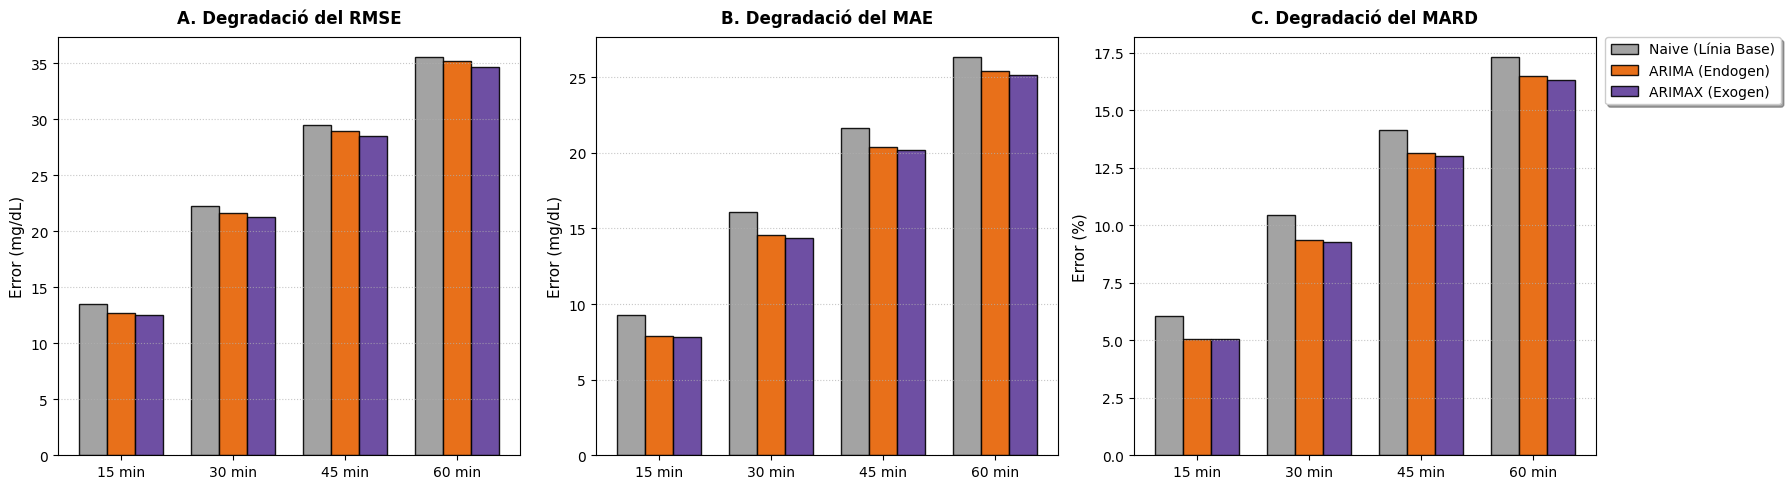

✅ S'ha guardat el panell global correctament a 'resultats_grafics\resultats_finals\comparativa_models_globals.png'


In [13]:
# Verificació de la disponibilitat de les mètriques globals
if 'df_metrics_naive' in locals() and 'df_metrics_arima' in locals() and 'df_metrics_arimax' in locals():
    
    print("S'està generant el panell comparatiu de mètriques globals...")

    # Definició d'etiquetes i posicions de l'eix X
    horitzons = ['15m', '30m', '45m', '60m']
    etiquetes_x = ['15 min', '30 min', '45 min', '60 min']
    x = np.arange(len(horitzons))
    width = 0.25

    # Funcions auxiliars per a extraure les columnes independentment del nom exacte (amb o sense unitats)
    def obtindre_valors(df, paraula_clau):
        columna = [col for col in df.columns if paraula_clau in col][0]
        # Assumim que l'ordre de les files és sempre 15m, 30m, 45m, 60m
        return df[columna].values

    # Inicialització del panell de 3 gràfics
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Paleta de colors coherent amb la resta del projecte
    color_base = '#999999'   # Gris
    color_arima = '#E66101'  # Taronja
    color_arimax = '#5E3C99' # Morat

    # Funció generalitzada per a dibuixar cada subplot
    def dibuixar_comparativa(ax, metrica, titol, ylabel):
        # Extracció dinàmica de les dades
        vals_base = obtindre_valors(df_metrics_naive, metrica)
        vals_arima = obtindre_valors(df_metrics_arima, metrica)
        vals_arimax = obtindre_valors(df_metrics_arimax, metrica)
        
        # Dibuix de les barres
        ax.bar(x - width, vals_base, width, label='Naive (Línia Base)', color=color_base, edgecolor='black', alpha=0.9)
        ax.bar(x, vals_arima, width, label='ARIMA (Endogen)', color=color_arima, edgecolor='black', alpha=0.9)
        ax.bar(x + width, vals_arimax, width, label='ARIMAX (Exogen)', color=color_arimax, edgecolor='black', alpha=0.9)
        
        # Configuració del format del subplot
        ax.set_title(titol, fontweight='bold', pad=10)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_xticks(x)
        ax.set_xticklabels(etiquetes_x)
        ax.grid(axis='y', linestyle=':', alpha=0.7)

    # Execució de les tres gràfiques
    dibuixar_comparativa(axes[0], 'RMSE', 'A. Degradació del RMSE', 'Error (mg/dL)')
    dibuixar_comparativa(axes[1], 'MAE', 'B. Degradació del MAE', 'Error (mg/dL)')
    dibuixar_comparativa(axes[2], 'MARD', 'C. Degradació del MARD', 'Error (%)')

    # Ajust de la llegenda a l'últim gràfic, per fora perquè no tape les barres
    axes[2].legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0., frameon=True, shadow=True)

    plt.tight_layout()
    
    # Exportació del panell en alta resolució
    ruta_comparativa = os.path.join(carpeta_grafiques, "comparativa_models_globals.png")
    plt.savefig(ruta_comparativa, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

    print(f"✅ S'ha guardat el panell global correctament a '{ruta_comparativa}'")
else:
    print("❌ Error: Manchen dades en memòria per a poder confeccionar el panell de mètriques globals.")

### 3. Validació Clínica: Graella d'Error de Clarke

Per finalitzar l'avaluació, aplique la Graella d'Error de Clarke per a cadascun dels quatre horitzons temporals. Aquesta eina analítica permet classificar l'exactitud de les prediccions no sols per la seua magnitud numèrica, sinó per la seua **rellevància clínica**. 
- Les **Zones A i B** representen prediccions segures on la decisió terapèutica (administració d'insulina o ingesta de carbohidrats) seria correcta.
- Les **Zones C, D i E** identifiquen errors que podrien derivar en accions clíniques perilloses.

Aquest panell permet contrastar visualment com l'ARIMAX manté una major proporció de punts en la Zona A a mesura que l'horitzó de predicció augmenta.

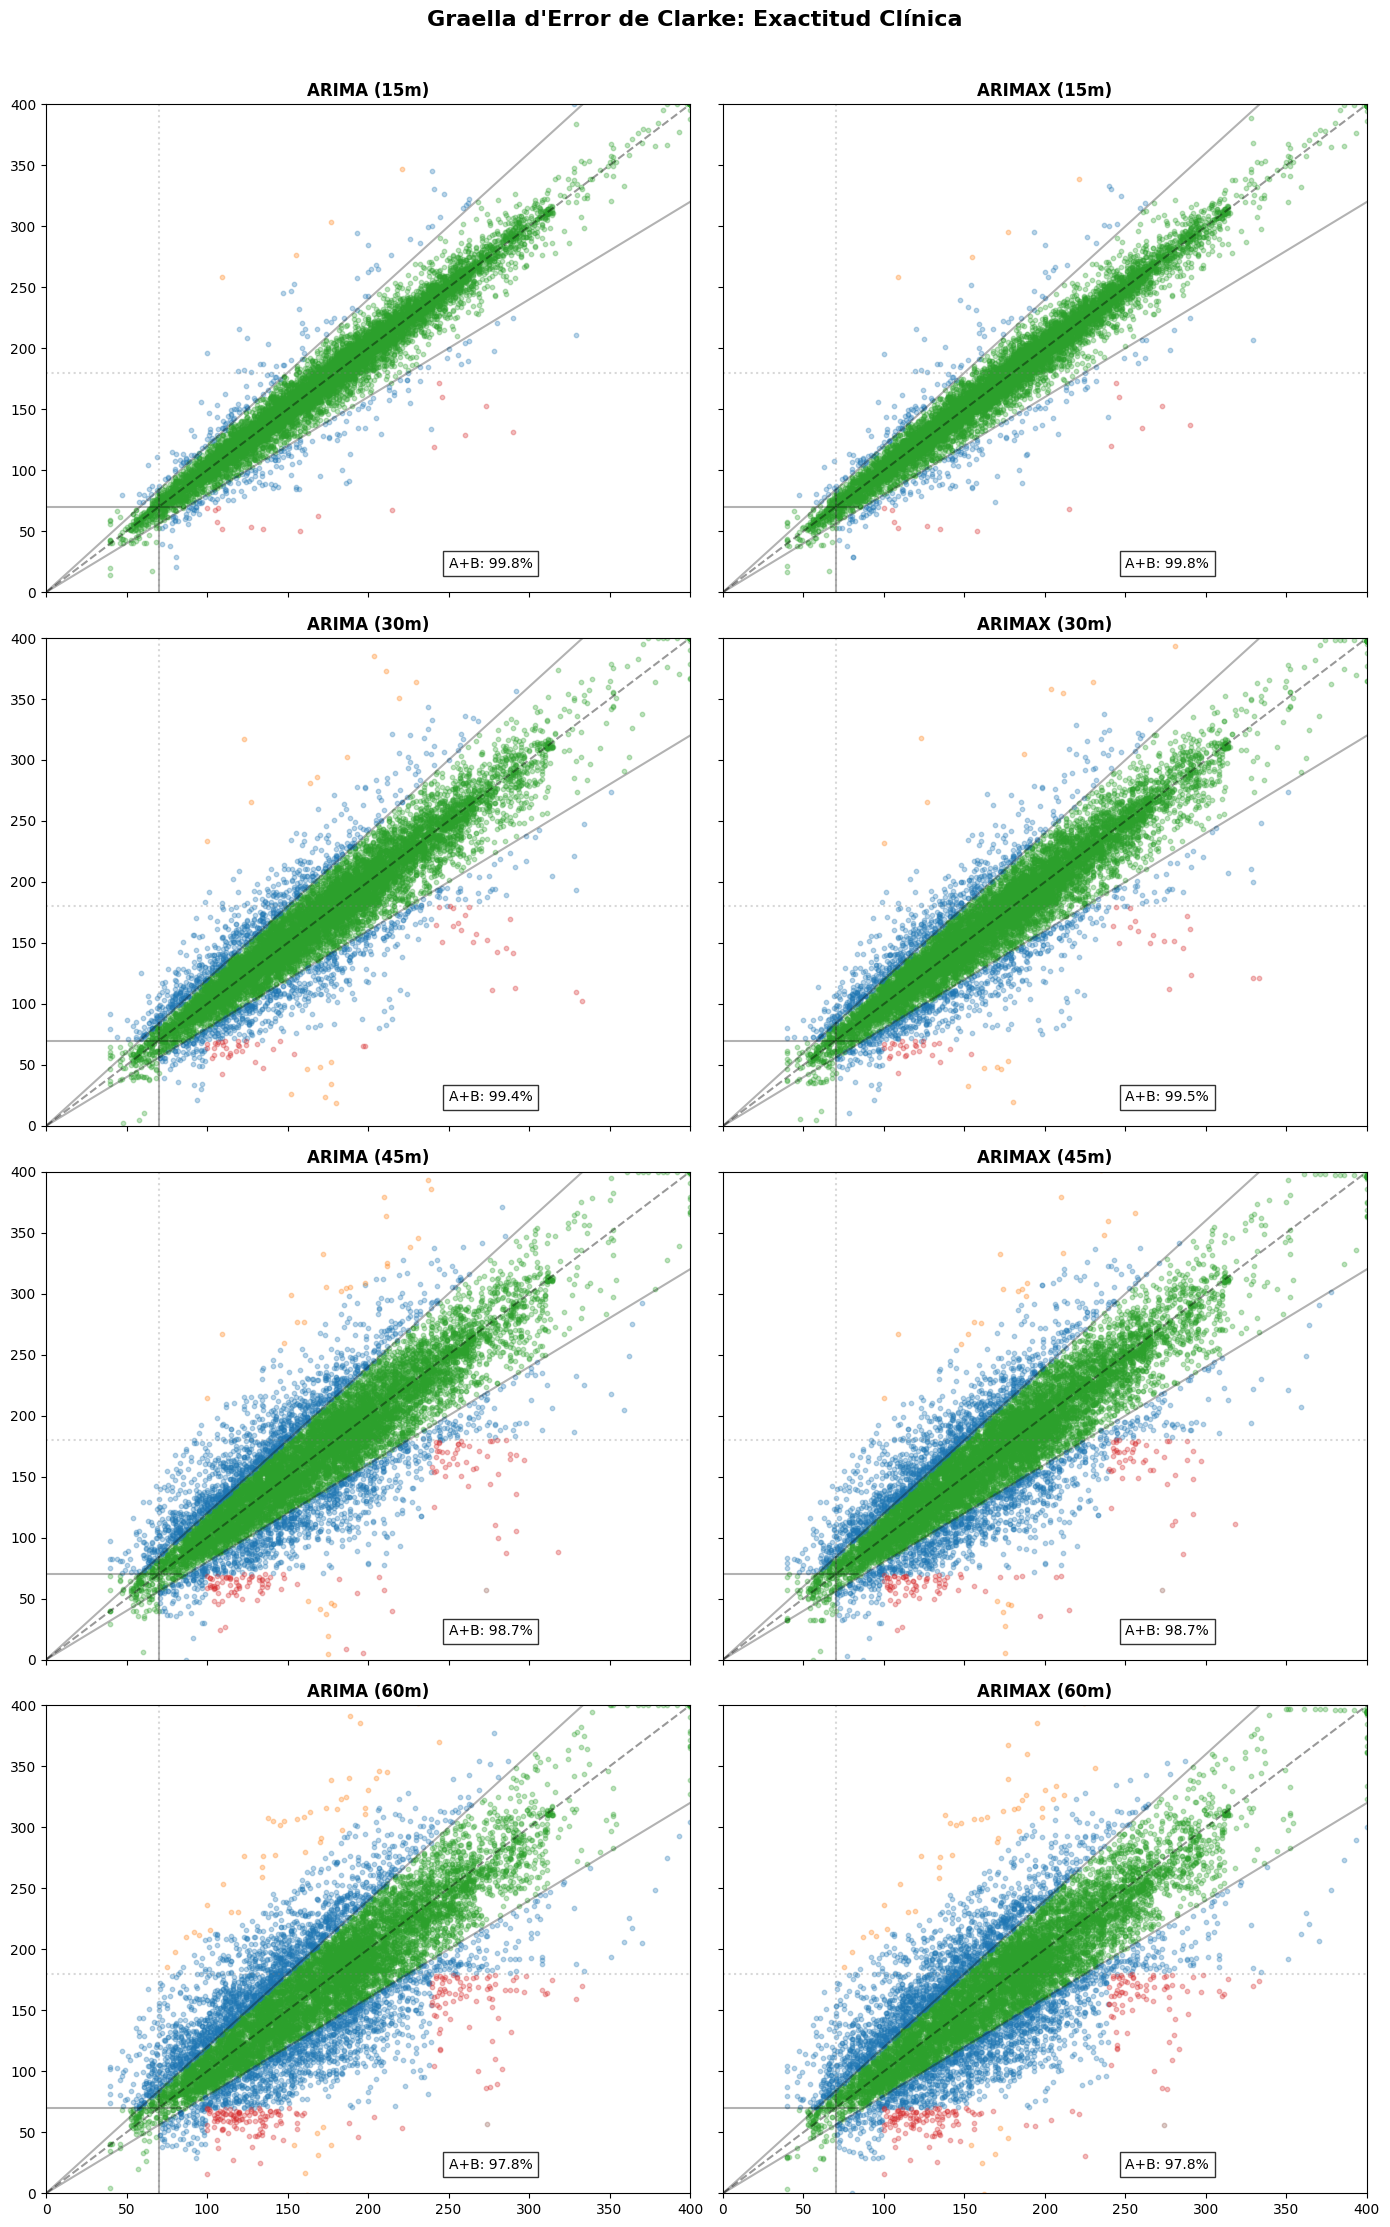

✅ Graella de Clarke guardada a 'resultats_grafics\resultats_finals\clarke_grid_horitzons.png'


In [14]:
# Definició de les zones de Clarke: Mapeig d'exactitud clínica
def categoritzar_zones_clarke(ref, pred):
    if (abs(ref - pred) <= 0.20 * ref) or (ref <= 70 and pred <= 70): return 'A'
    if (ref <= 70 and pred >= 180) or (ref >= 240 and pred <= 70): return 'E'
    if (ref >= 70 and ref <= 290 and pred >= ref + 110) or (ref >= 130 and ref <= 180 and pred <= ref - 110): return 'C'
    if (ref >= 100 and ref <= 240 and pred <= 70) or (ref >= 240 and pred >= 70 and pred <= 180): return 'D'
    return 'B'

colores_clarke = {'A': '#2ca02c', 'B': '#1f77b4', 'C': '#ff7f0e', 'D': '#d62728', 'E': '#8c564b'}

fig, axes = plt.subplots(4, 2, figsize=(14, 22), sharex=True, sharey=True)
horitzons = ['15m', '30m', '45m', '60m']

def dibuixar_clarke(ax, real, pred, titol):
    ax.set_xlim(0, 400); ax.set_ylim(0, 400)
    ax.set_title(titol, fontsize=12, fontweight='bold')
    # Dibuix de les línies mestres de la graella
    ax.plot([0, 400], [0, 400], 'k--', alpha=0.4) 
    ax.plot([0, 400], [0, 480], 'k-', alpha=0.3); ax.plot([0, 400], [0, 320], 'k-', alpha=0.3) 
    ax.plot([70, 70], [0, 84], 'k-', alpha=0.3); ax.plot([0, 84], [70, 70], 'k-', alpha=0.3)
    ax.axhline(180, color='gray', linestyle=':', alpha=0.3); ax.axvline(70, color='gray', linestyle=':', alpha=0.3)
    
    # Classificació i scatter plot
    zonas = [categoritzar_zones_clarke(r, p) for r, p in zip(real, pred)]
    df_temp = pd.DataFrame({'Real': real, 'Pred': pred, 'Zona': zonas})
    
    for zona in ['A', 'B', 'C', 'D', 'E']:
        d = df_temp[df_temp['Zona'] == zona]
        if not d.empty:
            ax.scatter(d['Real'], d['Pred'], c=colores_clarke[zona], label=f"Zona {zona}", alpha=0.3, s=10)
    
    # Càlcul zones segures
    a_b = (df_temp['Zona'].isin(['A', 'B']).sum() / len(df_temp)) * 100
    ax.text(250, 20, f"A+B: {a_b:.1f}%", fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

for i, h in enumerate(horitzons):
    dibuixar_clarke(axes[i, 0], df_pred_arima[f'Real_{h}'], df_pred_arima[f'Pred_{h}'], f'ARIMA ({h})')
    dibuixar_clarke(axes[i, 1], df_pred_arimax[f'Real_{h}'], df_pred_arimax[f'Pred_{h}'], f'ARIMAX ({h})')

plt.suptitle("Graella d'Error de Clarke: Exactitud Clínica", fontsize=16, y=1.01, fontweight='bold')
plt.tight_layout()
ruta_clarke = os.path.join(carpeta_grafiques, "clarke_grid_horitzons.png")
plt.savefig(ruta_clarke, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Graella de Clarke guardada a '{ruta_clarke}'")

### 4. Anàlisi Avançada d'Errors (Segmentació a 15 i 30 minuts)

Per a aprofundir en el comportament del sistema, genere una segmentació de l'error absolut mitjà relatiu (MARD) en funció de dues variables de context. Aquesta representació permet avaluar la robustesa de les prediccions sota diferents condicions, més enllà de les mètriques globals.
- La **Subgràfica A** mostra l'evolució de l'error segons l'hora del dia, la qual cosa permet observar com fluctua la precisió del model respecte a l'activitat diària del pacient (com ara els àpats).
- La **Subgràfica B** avalua l'error segons el nivell de glucosa real, permetent identificar l'estabilitat matemàtica del sistema en els diferents rangs clínics (hipoglucèmia, normoglucèmia i hiperglucèmia).

Aquest panell doble permet identificar visualment si els models presenten debilitats de rendiment específiques en certs moments del dia o en situacions de risc glucèmic.

S'està procedint a generar l'anàlisi avançada segmentada (Hora i Nivell de Glucosa)...


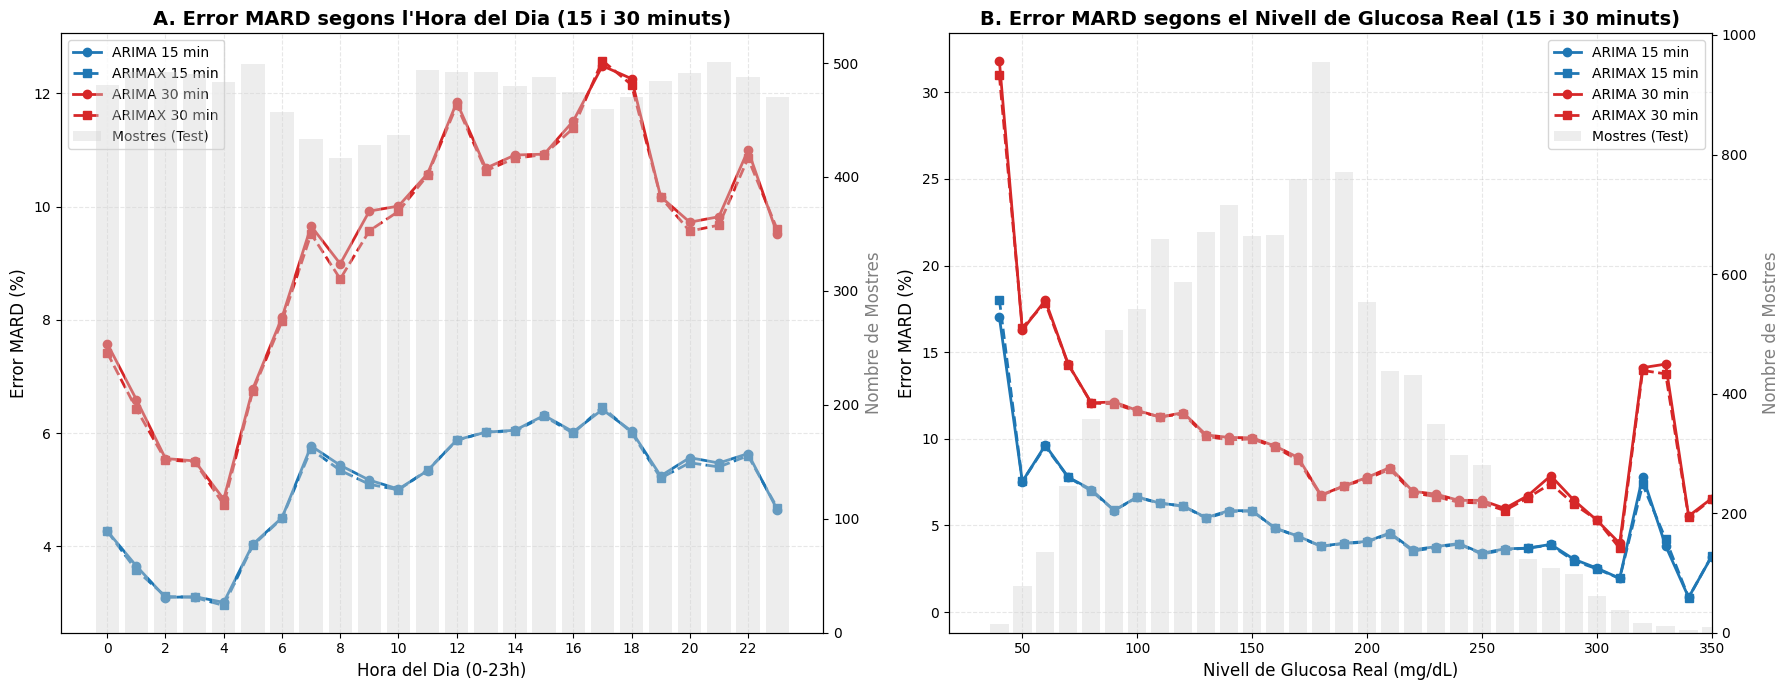

✅ S'ha guardat l'anàlisi de MARD complet a 'resultats_grafics\resultats_finals\analisi_avancada_complet.png'


In [15]:
print("S'està procedint a generar l'anàlisi avançada segmentada (Hora i Nivell de Glucosa)...")

# 1. Configuració de paràmetres (les rutes i imports ja s'han definit a la cel·la inicial)
bins = np.arange(40, 410, 10)

def calcula_mard(grupo):
    return (abs(grupo['Real'] - grupo['Pred']) / grupo['Real']).mean() * 100

# 2. Inicialització de la figura doble
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
ax1 = axes[0]
ax2 = axes[1]

# 3. Fons de distribució (Barres grises de mostres utilitzant les dades de Test)
df_dist = df_pred_arima[['Timestamp_Pred', 'Real_15m']].copy()
df_dist['Hora'] = df_dist['Timestamp_Pred'].dt.hour
df_dist['Glucosa_Bin'] = pd.cut(df_dist['Real_15m'], bins=bins, labels=bins[:-1])

conteo_hora = df_dist.groupby('Hora').size()
conteo_glucosa = df_dist.groupby('Glucosa_Bin', observed=False).size()

# Subgràfica A: Eix secundari (Mostres)
ax1_twin = ax1.twinx()
ax1_twin.bar(conteo_hora.index, conteo_hora.values, color='lightgray', alpha=0.4, label='Mostres (Test)')
ax1_twin.set_ylabel('Nombre de Mostres', fontsize=12, color='gray')

# Subgràfica B: Eix secundari (Mostres)
ax2_twin = ax2.twinx()
valid_bins = conteo_glucosa.dropna().index
ax2_twin.bar(valid_bins, conteo_glucosa.dropna().values, width=8, color='lightgray', alpha=0.4, label='Mostres (Test)')
ax2_twin.set_ylabel('Nombre de Mostres', fontsize=12, color='gray')

# 4. Configuració visual dels eixos principals
ax1.set_title("A. Error MARD segons l'Hora del Dia (15 i 30 minuts)", fontsize=14, fontweight='bold')
ax1.set_xlabel("Hora del Dia (0-23h)", fontsize=12)
ax1.set_ylabel("Error MARD (%)", fontsize=12)
ax1.set_xticks(range(0, 24, 2))
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.patch.set_visible(False) 

ax2.set_title("B. Error MARD segons el Nivell de Glucosa Real (15 i 30 minuts)", fontsize=14, fontweight='bold')
ax2.set_xlabel("Nivell de Glucosa Real (mg/dL)", fontsize=12)
ax2.set_ylabel("Error MARD (%)", fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.3)
ax2.set_xlim(right=350)
ax2.patch.set_visible(False)

# 5. Bucle de processament de models i horitzons
configuracions = [(15, '#1f77b4'), (30, '#d62728')]

for h, color in configuracions:
    col_real = f'Real_{h}m'
    col_pred = f'Pred_{h}m'
    
    # Processament ARIMA
    df_h_arima = df_pred_arima[['Pacient', 'Timestamp_Pred', col_real, col_pred]].copy()
    df_h_arima.rename(columns={col_real: 'Real', col_pred: 'Pred'}, inplace=True)
    df_h_arima['Hora'] = df_h_arima['Timestamp_Pred'].dt.hour
    df_h_arima['Glucosa_Bin'] = pd.cut(df_h_arima['Real'], bins=bins, labels=bins[:-1])
    
    mard_hora_arima = df_h_arima.groupby('Hora').apply(calcula_mard)
    mard_gluc_arima = df_h_arima.groupby('Glucosa_Bin', observed=False).apply(calcula_mard)
    
    ax1.plot(mard_hora_arima.index, mard_hora_arima.values, marker='o', linewidth=2, color=color, label=f'ARIMA {h} min')
    ax2.plot(mard_gluc_arima.index.astype(int), mard_gluc_arima.values, marker='o', linewidth=2, color=color, label=f'ARIMA {h} min')
    
    # Processament ARIMAX
    df_h_arimax = df_pred_arimax[['Pacient', 'Timestamp_Pred', col_real, col_pred]].copy()
    df_h_arimax.rename(columns={col_real: 'Real', col_pred: 'Pred'}, inplace=True)
    df_h_arimax['Hora'] = df_h_arimax['Timestamp_Pred'].dt.hour
    df_h_arimax['Glucosa_Bin'] = pd.cut(df_h_arimax['Real'], bins=bins, labels=bins[:-1])
    
    mard_hora_arimax = df_h_arimax.groupby('Hora').apply(calcula_mard)
    mard_gluc_arimax = df_h_arimax.groupby('Glucosa_Bin', observed=False).apply(calcula_mard)
    
    ax1.plot(mard_hora_arimax.index, mard_hora_arimax.values, marker='s', linewidth=2, color=color, linestyle='--', label=f'ARIMAX {h} min')
    ax2.plot(mard_gluc_arimax.index.astype(int), mard_gluc_arimax.values, marker='s', linewidth=2, color=color, linestyle='--', label=f'ARIMAX {h} min')

# 6. Unificació de llegendes
lines, labels_leg = ax1.get_legend_handles_labels()
lines2, labels2_leg = ax1_twin.get_legend_handles_labels()
ax1.legend(lines + lines2, labels_leg + labels2_leg, loc='upper left')

lines_b, labels_b = ax2.get_legend_handles_labels()
lines2_b, labels2_b = ax2_twin.get_legend_handles_labels()
ax2.legend(lines_b + lines2_b, labels_b + labels2_b, loc='upper right')

plt.tight_layout()

# 7. Guardat reutilitzant la ruta mestre
ruta_avanzada = os.path.join(carpeta_grafiques, "analisi_avancada_complet.png")
plt.savefig(ruta_avanzada, dpi=300, facecolor='white')
plt.show()

print(f"✅ S'ha guardat l'anàlisi de MARD complet a '{ruta_avanzada}'")

### 5. Dispersió (Boxplots Comparatius)

Per a avaluar l'estabilitat de les prediccions a escala individual, construïsc un panell de diagrames de caixa (*boxplots*) per a cadascun dels quatre horitzons temporals. Aquesta eina gràfica permet exposar la variància real i la dispersió de l'error relatiu pacient per pacient.
- Les **Caixes i els seus quartils** mostren on es concentra la major part de l'error predictiu per a cada subjecte, reflectint l'estabilitat general del model.
- Els **Extrems (bigotis)** il·lustren la inestabilitat màxima, identificant els pics d'error que podrien quedar emmascarats en una simple mitjana aritmètica.

Aquesta visualització facilita la comparativa directa entre l'arquitectura ARIMA i l'ARIMAX, permetent comprovar com es degrada la fiabilitat de cada model a mesura que la finestra de predicció s'allunya en el temps.

Generant el panell de Boxplots d'errors per als 4 horitzons (ARIMA vs ARIMAX)...


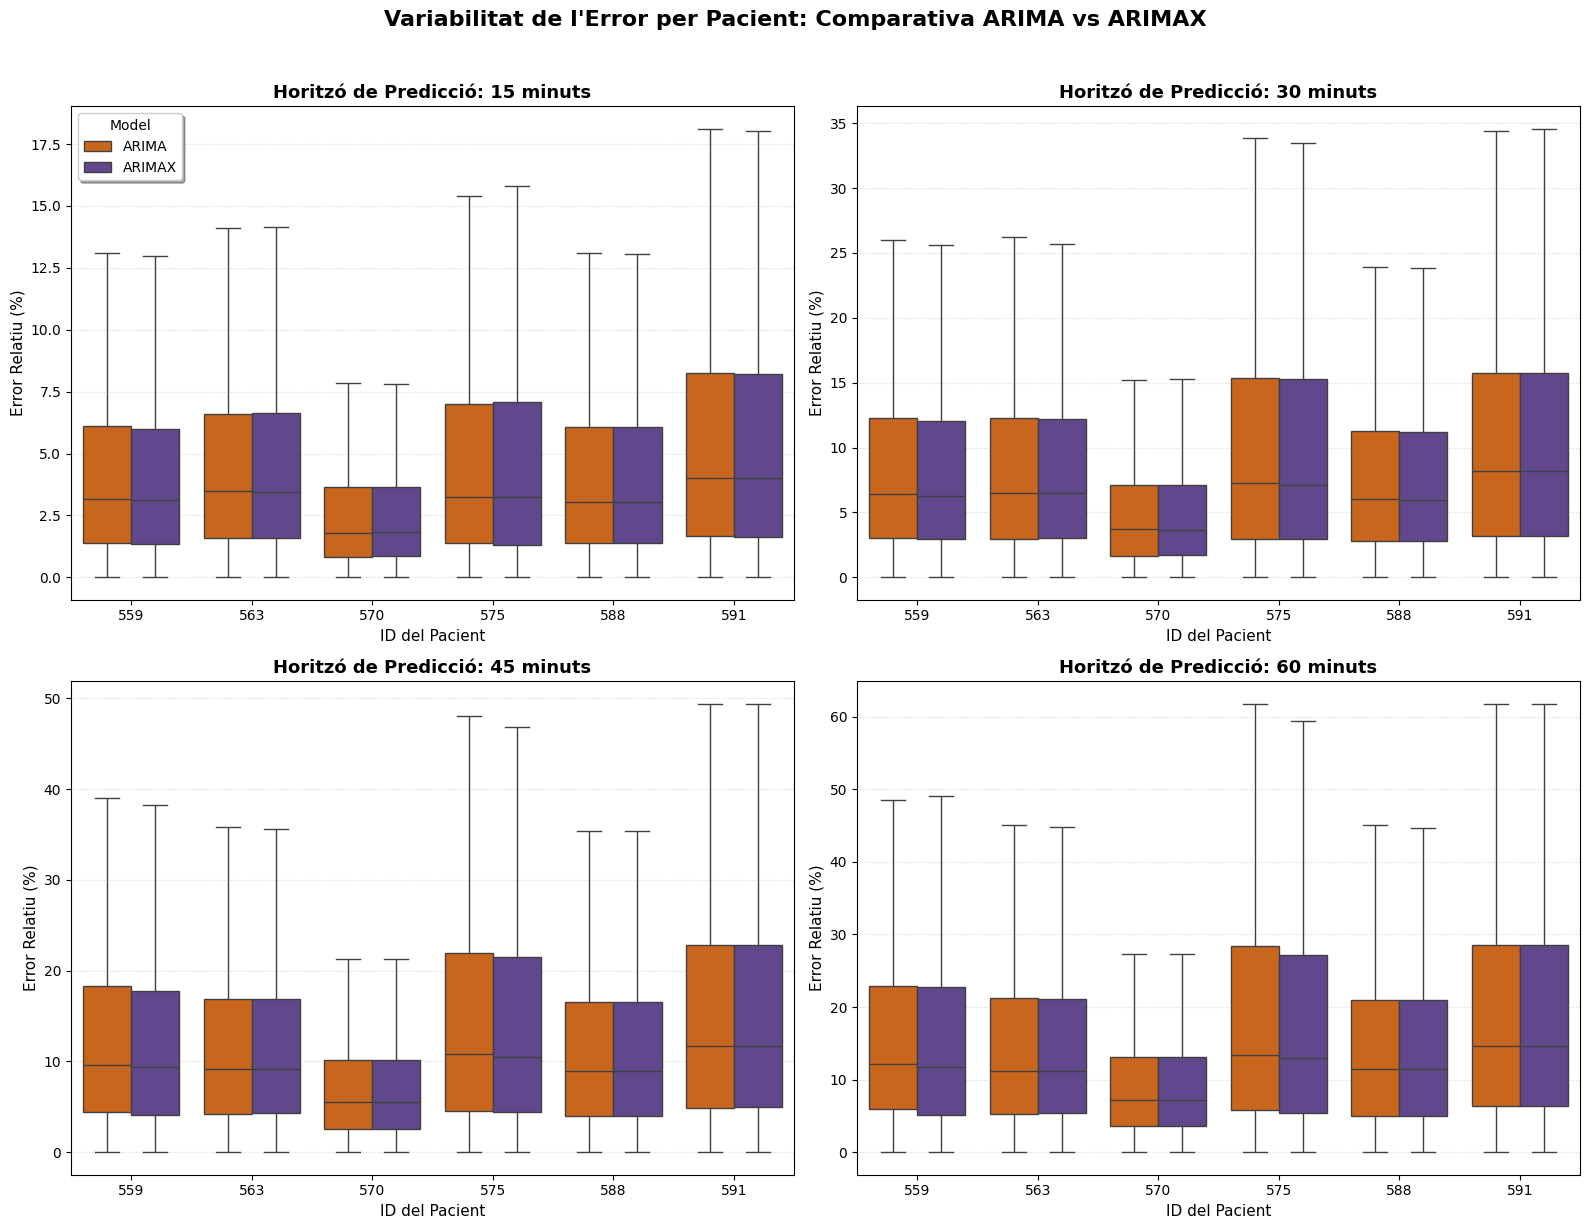

✅ S'ha guardat el panell de variabilitat correctament a 'resultats_grafics\resultats_finals\variabilitat_mard_horitzons.png'


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Generant el panell de Boxplots d'errors per als 4 horitzons (ARIMA vs ARIMAX)...")

# 1. Inicialització de la graella 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

horitzons_cols = [15, 30, 45, 60]
titols_horitzons = ['15 minuts', '30 minuts', '45 minuts', '60 minuts']

paleta_colors = {
    'ARIMA': '#E66101', 
    'ARIMAX': '#5E3C99'
}

# Calcula l'error per a CADA mostra, sense fer la mitjana
def calcula_errors_individuals(df, h):
    col_real = f'Real_{h}m'
    col_pred = f'Pred_{h}m'
    
    df_temp = df[['Pacient', col_real, col_pred]].copy()
    # Calculem l'error absolut relatiu per a cada fila (predicció)
    df_temp['MARD'] = (abs(df_temp[col_real] - df_temp[col_pred]) / df_temp[col_real]) * 100
    
    return df_temp[['Pacient', 'MARD']]

for i, (h, h_titol) in enumerate(zip(horitzons_cols, titols_horitzons)):
    
    # 2. Càlcul de tots els errors individuals
    df_arima_errors = calcula_errors_individuals(df_pred_arima, h)
    df_arima_errors['Model'] = 'ARIMA'
    
    df_arimax_errors = calcula_errors_individuals(df_pred_arimax, h)
    df_arimax_errors['Model'] = 'ARIMAX'
    
    # 3. Concatenem les dades milers de mostres
    df_box = pd.concat([df_arima_errors, df_arimax_errors], ignore_index=True)
    
    # 4. Dibuixem el boxplot vertader
    sns.boxplot(ax=axes[i], data=df_box, x='Pacient', y='MARD', hue='Model', 
                palette=paleta_colors, showfliers=False)
    
    # Format i estil
    axes[i].set_title(f"Horitzó de Predicció: {h_titol}", fontsize=13, fontweight='bold')
    axes[i].set_ylabel("Error Relatiu (%)", fontsize=11)
    axes[i].set_xlabel("ID del Pacient", fontsize=11)
    axes[i].grid(axis='y', linestyle=':', alpha=0.5)
    
    # Neteja de llegendes
    if i != 0:
        axes[i].get_legend().remove()
    else:
        axes[i].legend(title="Model", loc='upper left', frameon=True, shadow=True)

# Títol global i guardat
plt.suptitle("Variabilitat de l'Error per Pacient: Comparativa ARIMA vs ARIMAX", fontsize=16, y=1.02, fontweight='bold')
plt.tight_layout()

# Guardat reutilitzant la ruta central
ruta_boxplots = os.path.join(carpeta_grafiques, "variabilitat_mard_horitzons.png")
plt.savefig(ruta_boxplots, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"✅ S'ha guardat el panell de variabilitat correctament a '{ruta_boxplots}'")

### 6. Error Relatiu Multihoritzó - Model ARIMA

Per a analitzar la distribució i la direccionalitat dels residus de l'arquitectura endògena, genere un panell de gràfics de dispersió (*scatterplots*) que enfronta l'error relatiu percentual contra els valors reals de glucosa. Aquesta visualització desglossa el comportament del model ARIMA en els quatre horitzons temporals d'estudi.
- L'**Eix horitzontal (Glucosa Real)** permet identificar si el patró de fallada del model depèn de l'estat metabòlic del pacient, segmentat pels llindars crítics d'hipoglucèmia i hiperglucèmia.
- L'**Eix vertical (Error Relatiu %)** reflecteix la magnitud de la desviació i la seua direcció, indicant si el model tendeix a sobreestimar (errors positius) o a subestimar (errors negatius) la realitat.

Aquest mapa de residus facilita la detecció visual de qualsevol biaix sistemàtic del model ARIMA a mesura que les finestres temporals s'estiren i el volum d'error s'amplifica.

S'està generant l'anàlisi de residus per horitzó (Model ARIMA)...


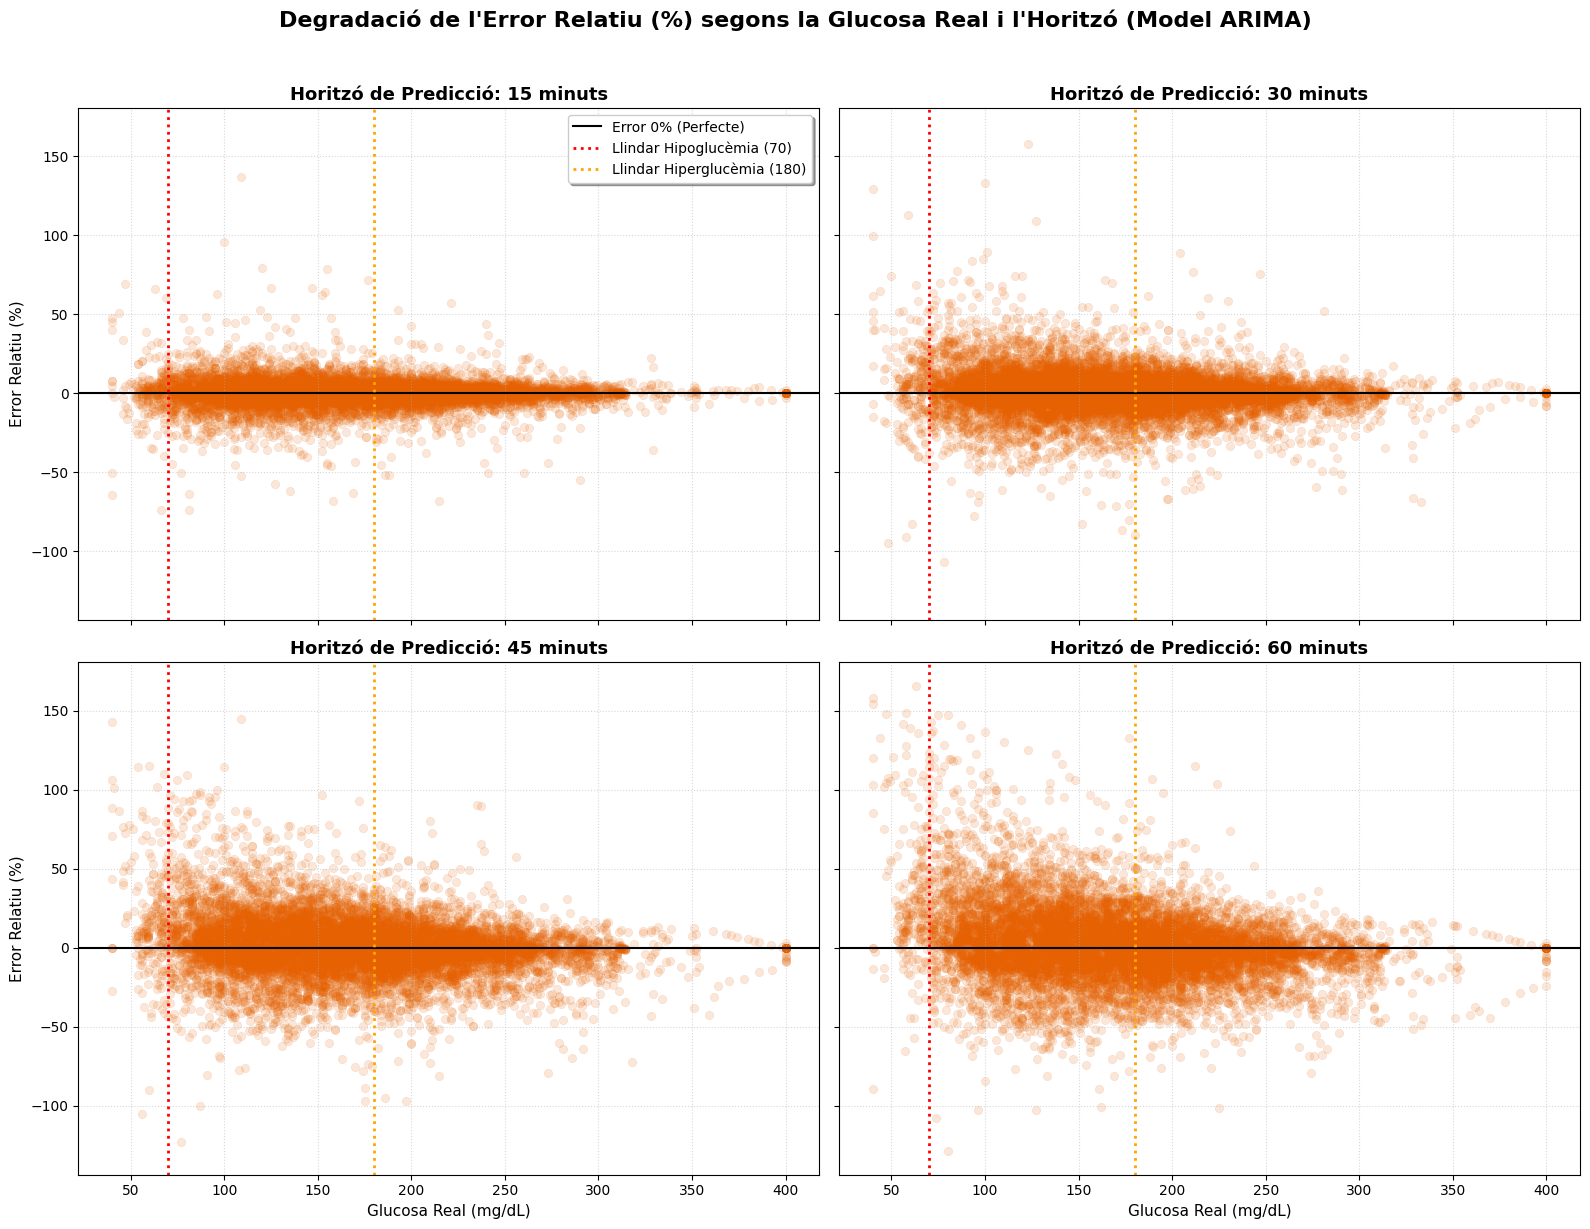

✅ S'ha guardat la gràfica de residus d'ARIMA correctament a 'resultats_grafics\resultats_finals\error_relatiu_multihoritzo_arima.png'


In [17]:
print("S'està generant l'anàlisi de residus per horitzó (Model ARIMA)...")

# 1. Inicialització de la figura doble (panell 2x2)
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True, sharex=True)
axes = axes.flatten()

horitzons = [15, 30, 45, 60]
titols = ['15 minuts', '30 minuts', '45 minuts', '60 minuts']

for i, ax in enumerate(axes):
    h = horitzons[i]
    col_real = f'Real_{h}m'
    col_pred = f'Pred_{h}m'
    
    # 2. Creem un dataframe temporal per a calcular l'error relatiu d'aquest horitzó
    df_h = df_pred_arima[['Pacient', col_real, col_pred]].copy()
    df_h['Error_Relatiu'] = ((df_h[col_pred] - df_h[col_real]) / df_h[col_real]) * 100
    
    # 3. Dibuixem el scatterplot amb el taronja corporatiu de l'ARIMA
    sns.scatterplot(x=col_real, y='Error_Relatiu', data=df_h, alpha=0.15, 
                    color='#E66101', edgecolor=None, ax=ax)
    
    # Línies clíniques de referència mestre
    ax.axhline(0, color='black', linestyle='-', linewidth=1.5, label='Error 0% (Perfecte)')
    ax.axvline(70, color='red', linestyle=':', linewidth=2, label='Llindar Hipoglucèmia (70)')
    ax.axvline(180, color='orange', linestyle=':', linewidth=2, label='Llindar Hiperglucèmia (180)')
    
    # Format, graella i etiquetes
    ax.set_title(f"Horitzó de Predicció: {titols[i]}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Glucosa Real (mg/dL)", fontsize=11)
    ax.set_ylabel("Error Relatiu (%)", fontsize=11)
    ax.grid(True, linestyle=':', alpha=0.5)
    
    if i == 0: 
        ax.legend(loc='upper right', frameon=True, shadow=True)

# Títol global i exportació neta
plt.suptitle("Degradació de l'Error Relatiu (%) segons la Glucosa Real i l'Horitzó (Model ARIMA)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

ruta_residus_arima = os.path.join(carpeta_grafiques, "error_relatiu_multihoritzo_arima.png")
plt.savefig(ruta_residus_arima, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"✅ S'ha guardat la gràfica de residus d'ARIMA correctament a '{ruta_residus_arima}'")

### 7. Error Relatiu Multihoritzó - Model ARIMAX

Per a analitzar la distribució i la direccionalitat dels residus de l'arquitectura exògena, genere un panell de gràfics de dispersió (*scatterplots*) que enfronta l'error relatiu percentual contra els valors reals de glucosa. Aquesta visualització desglossa el comportament del model ARIMAX en els quatre horitzons temporals d'estudi.
- L'**Eix horitzontal (Glucosa Real)** permet identificar si el patró de fallada del model depèn de l'estat metabòlic del pacient, segmentat pels llindars crítics d'hipoglucèmia i hiperglucèmia.
- L'**Eix vertical (Error Relatiu %)** reflecteix la magnitud de la desviació i la seua direcció, indicant si el model tendeix a sobreestimar (errors positius) o a subestimar (errors negatius) la realitat.

Aquest mapa de residus facilita la detecció visual de qualsevol biaix sistemàtic del model ARIMAX a mesura que les finestres temporals s'estiren i el volum d'error s'amplifica.

S'està generant l'anàlisi de residus per horitzó (Model ARIMAX)...


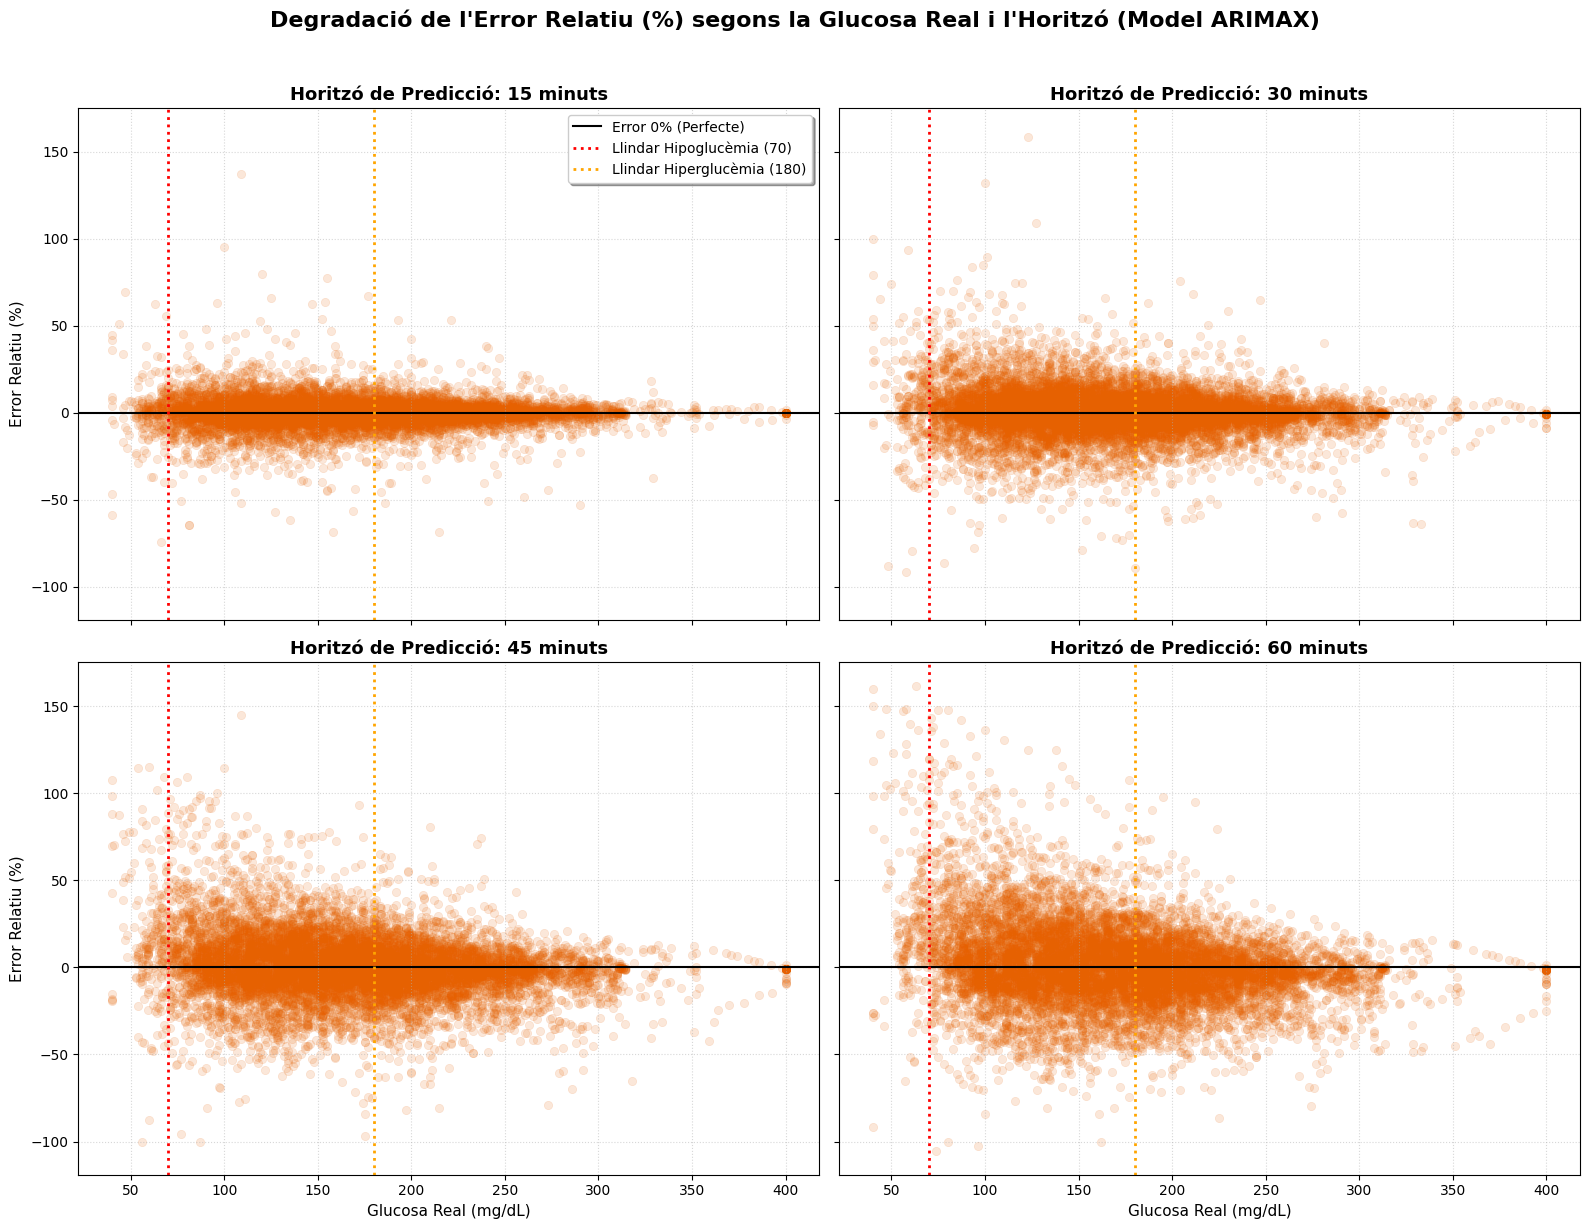

✅ S'ha guardat la gràfica de residus d'ARIMAX correctament a 'resultats_grafics\resultats_finals\error_relatiu_multihoritzo_arimax.png'


In [18]:
print("S'està generant l'anàlisi de residus per horitzó (Model ARIMAX)...")

# 1. Inicialització de la figura doble (panell 2x2)
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True, sharex=True)
axes = axes.flatten()

horitzons = [15, 30, 45, 60]
titols = ['15 minuts', '30 minuts', '45 minuts', '60 minuts']

for i, ax in enumerate(axes):
    h = horitzons[i]
    col_real = f'Real_{h}m'
    col_pred = f'Pred_{h}m'
    
    # 2. Creem un dataframe temporal per a calcular l'error relatiu d'aquest horitzó
    df_h = df_pred_arimax[['Pacient', col_real, col_pred]].copy()
    df_h['Error_Relatiu'] = ((df_h[col_pred] - df_h[col_real]) / df_h[col_real]) * 100
    
    # 3. Dibuixem el scatterplot amb el mateix color que l'ARIMA
    sns.scatterplot(x=col_real, y='Error_Relatiu', data=df_h, alpha=0.15, 
                    color='#E66101', edgecolor=None, ax=ax)
    
    # Línies clíniques de referència mestre
    ax.axhline(0, color='black', linestyle='-', linewidth=1.5, label='Error 0% (Perfecte)')
    ax.axvline(70, color='red', linestyle=':', linewidth=2, label='Llindar Hipoglucèmia (70)')
    ax.axvline(180, color='orange', linestyle=':', linewidth=2, label='Llindar Hiperglucèmia (180)')
    
    # Format, graella i etiquetes
    ax.set_title(f"Horitzó de Predicció: {titols[i]}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Glucosa Real (mg/dL)", fontsize=11)
    ax.set_ylabel("Error Relatiu (%)", fontsize=11)
    ax.grid(True, linestyle=':', alpha=0.5)
    
    if i == 0: 
        ax.legend(loc='upper right', frameon=True, shadow=True)

# Títol global i exportació neta
plt.suptitle("Degradació de l'Error Relatiu (%) segons la Glucosa Real i l'Horitzó (Model ARIMAX)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

ruta_residus_arimax = os.path.join(carpeta_grafiques, "error_relatiu_multihoritzo_arimax.png")
plt.savefig(ruta_residus_arimax, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"✅ S'ha guardat la gràfica de residus d'ARIMAX correctament a '{ruta_residus_arimax}'")

### 8. Taula Resum de Mètriques Globals

En aquesta taula s'exposen els valors mitjans de les mètriques d'error (*Root Mean Square Error*, *Mean Absolute Error* i *Mean Absolute Relative Difference*) calculats sobre el conjunt de validació (*test*) per als tres models estudiats. Aquestes mètriques proporcionen una visió global de l'exactitud de les prediccions, condensant el rendiment del sistema en una única comparativa.

Els valors presentats serveixen com a base per a quantificar la millora incremental en l'exactitud de la predicció a mesura que s'incorporen estructures auto-regressives (ARIMA) i variables exògenes (ARIMAX) respecte al model de referència *Naive*.

In [19]:
print("Generant la taula resum de mètriques globals consolidada...")

# 1. Funció per a netejar els noms i obtenir la mitjana global de cada model
def obtenir_mitjana_global(df):
    # Seleccionem només les columnes numèriques rellevants (ignorem 'Horitzó')
    cols_numeriques = df.select_dtypes(include=[np.number]).columns
    return df[cols_numeriques].mean()

# 2. Obtenim les mitjanes (netejant els noms de les columnes al vol)
resum_naive = obtenir_mitjana_global(df_metrics_naive).rename({'MARD (%)': 'MARD'})
resum_arima = obtenir_mitjana_global(df_metrics_arima).rename({'RMSE (mg/dL)': 'RMSE', 'MAE (mg/dL)': 'MAE', 'MARD (%)': 'MARD'})
resum_arimax = obtenir_mitjana_global(df_metrics_arimax).rename({'RMSE (mg/dL)': 'RMSE', 'MAE (mg/dL)': 'MAE', 'MARD (%)': 'MARD'})

# 3. Construïm la taula final
taula_final = pd.DataFrame({
    'Naive': resum_naive,
    'ARIMA': resum_arima,
    'ARIMAX': resum_arimax
}).T[['RMSE', 'MAE', 'MARD']].round(3)

# 4. Visualització i guardat
display(taula_final)

ruta_taula = os.path.join(carpeta_grafiques, "resum_metriques_globals.csv")
taula_final.to_csv(ruta_taula)

print(f"✅ Taula generada correctament a '{ruta_taula}'")

Generant la taula resum de mètriques globals consolidada...


,RMSE,MAE,MARD
Naive,25.197,18.332,11.982
ARIMA,24.627,17.058,11.012
ARIMAX,24.232,16.882,10.907


✅ Taula generada correctament a 'resultats_grafics\resultats_finals\resum_metriques_globals.csv'


### 9. Visualització de Sèries Temporals: Resposta Metabòlica

#### 9.1. Anàlisi de la Resposta Metabòlica: Latència de l'Insulina (Bolus)

A continuació, es visualitza la capacitat del model multivariant per capturar la dinàmica farmacocinètica de l'insulina. A diferència de les mètriques agregades, aquesta representació temporal permet avaluar com el model prediu la caiguda de la glucosa provocada per un bolus d'insulina ràpida. L'eix temporal s'ha alineat reflectint el moment real en què ocorre l'esdeveniment ($t$) en contrast amb l'efecte predictiu i real desplaçat a 30 minuts ($t+30$), respectant així el temps de latència metabòlica de l'hormona.

Carregant i fusionant les dades per a l'anàlisi de sèries temporals...


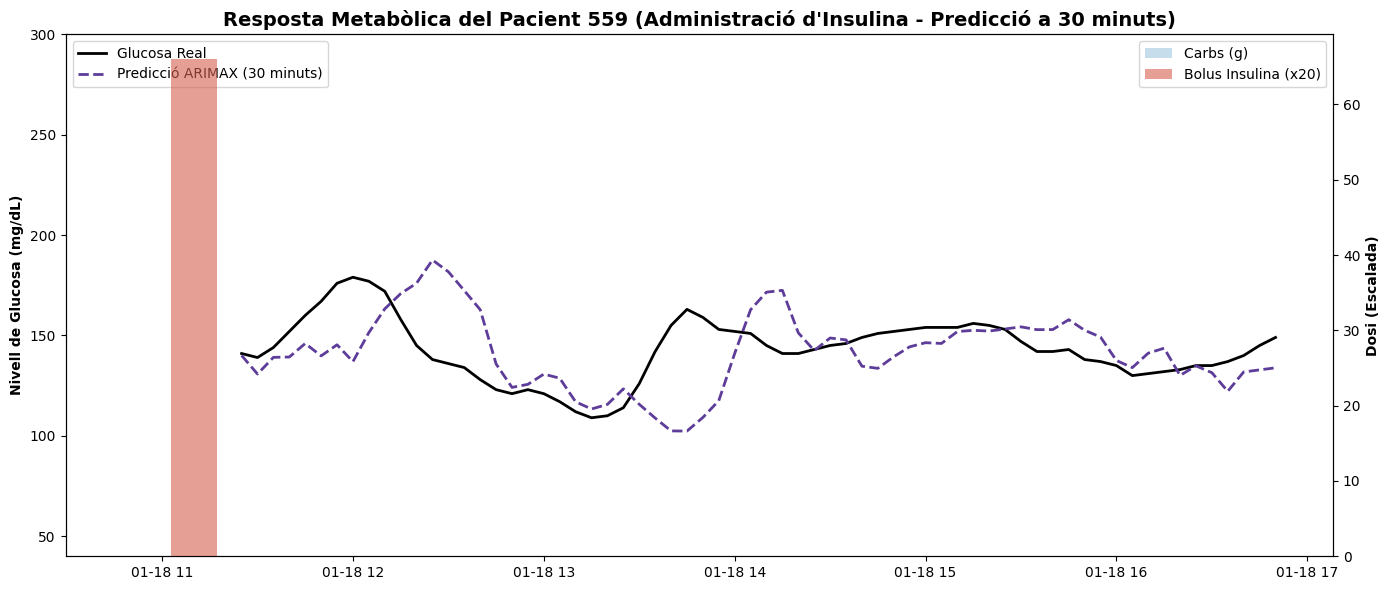

✅ Imatge generada correctament a 'resultats_grafics\resultats_finals\resposta_metabolica_insulina.png'


In [20]:
print("Carregant i fusionant les dades per a l'anàlisi de sèries temporals...")

# 1. Carregue les dades preprocessades i prepare els dataframes
df_exogens = pd.read_csv("dades_preprocessades/dataset_test_net.csv") 
df_exogens['timestamp'] = pd.to_datetime(df_exogens['timestamp'])

df_pred_arimax['timestamp'] = pd.to_datetime(df_pred_arimax['Timestamp_Pred'])
df_pred_arimax['pacient_id'] = df_pred_arimax['Pacient'].astype(int)

# 2. Faig el merge definitiu utilitzant les claus temporals i d'identificació
df_final = pd.merge(
    df_pred_arimax, 
    df_exogens[['timestamp', 'pacient_id', 'carbs', 'bolus']], 
    on=['timestamp', 'pacient_id'], 
    how='left'
).fillna(0)

# 3. Cerque automàticament el primer esdeveniment d'injecció per al pacient 559
df_p559 = df_final[df_final['Pacient'].astype(str) == '559'].copy()
bolus_p559 = df_p559[df_p559['bolus'] > 0]

if not bolus_p559.empty:
    data_inici_insulina = bolus_p559['timestamp'].min()
    pacient_target_insulina = '559'
    
    # 4. Filtre una finestra temporal al voltant del moment clau (afegeix copy() per evitar warnings de Pandas)
    sub_insulina = df_p559[
        (df_p559['timestamp'] >= data_inici_insulina - pd.Timedelta(hours=2)) & 
        (df_p559['timestamp'] <= data_inici_insulina + pd.Timedelta(hours=8))
    ].sort_values('timestamp').copy()

    # Cree l'eix correcte (t + 30 min) exclusivament per a dibuixar la glucosa target
    sub_insulina['Timestamp_Target'] = sub_insulina['timestamp'] + pd.Timedelta(minutes=30)

    # 5. Genere la gràfica amb l'estil estandarditzat
    fig, ax1 = plt.subplots(figsize=(14, 6))
    
    # Utilitze el nou 'Timestamp_Target' per a les corbes de glucosa
    ax1.plot(sub_insulina['Timestamp_Target'], sub_insulina['Real_30m'], label='Glucosa Real', color='black', linewidth=2)
    ax1.plot(sub_insulina['Timestamp_Target'], sub_insulina['Pred_30m'], label='Predicció ARIMAX (30 minuts)', color='#5E3C99', linewidth=2, linestyle='--')
    ax1.set_ylabel("Nivell de Glucosa (mg/dL)", fontweight='bold')
    ax1.set_ylim(40, 300)
    
    ax2 = ax1.twinx()
    # Mantinc el 'timestamp' original per a ubicar l'esdeveniment en el temps real
    ax2.bar(sub_insulina['timestamp'], sub_insulina['carbs'], color='#4393C3', alpha=0.3, label='Carbs (g)', width=0.01)
    ax2.bar(sub_insulina['timestamp'], sub_insulina['bolus'] * 20, color='#D6604D', alpha=0.6, label='Bolus Insulina (x20)', width=0.01)
    ax2.set_ylabel("Dosi (Escalada)", fontweight='bold')
    
    plt.title(f"Resposta Metabòlica del Pacient {pacient_target_insulina} (Administració d'Insulina - Predicció a 30 minuts)", fontsize=14, fontweight='bold')
    ax1.legend(loc='upper left', frameon=True)
    ax2.legend(loc='upper right', frameon=True)
    
    plt.tight_layout()
    
    # 6. Visualització i guardat
    ruta_grafica_insulina = os.path.join(carpeta_grafiques, "resposta_metabolica_insulina.png")
    plt.savefig(ruta_grafica_insulina, bbox_inches='tight', dpi=300)
    plt.show()
    
    print(f"✅ Imatge generada correctament a '{ruta_grafica_insulina}'")
else:
    print("No s'ha trobat cap registre de bolus per a aquest pacient i període.")

#### 9.2. Anàlisi de la Resposta Metabòlica: Absorció de Carbohidrats (Àpats)

De manera anàloga a l'insulina, s'avalua la resposta del model davant les ingestes de carbohidrats, les quals provoquen una pujada de la glucosa per l'absorció intestinal. Mantenint l'alineament temporal correcte, les ingestes es mostren en el moment exacte de l'esdeveniment ($t$), mentre que les corbes real i predictiva es posicionen a $t+30$ minuts. Això permet comprovar visualment si el model reflecteix fidelment el pic glucèmic postprandial sense anticipar-se erròniament a l'absorció de l'àpat.

Generant la gràfica d'ingesta de carbohidrats...


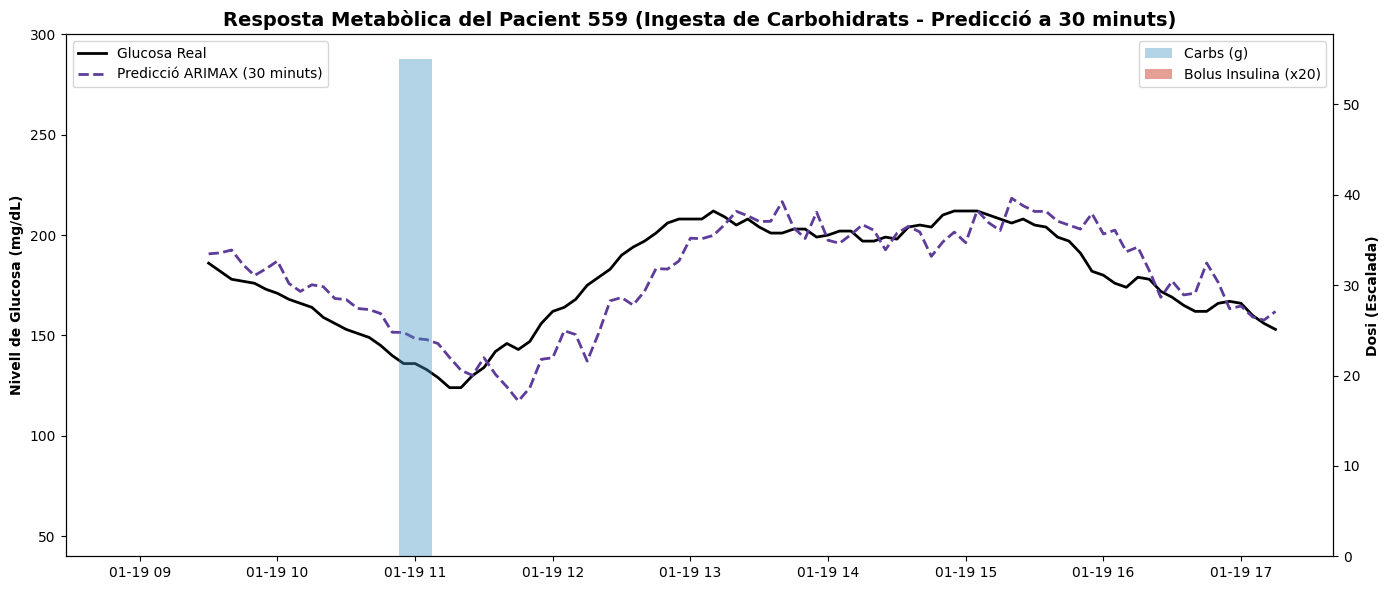

✅ Imatge generada correctament a 'resultats_grafics\resultats_finals\resposta_metabolica_carbohidrats.png'


In [21]:
print("Generant la gràfica d'ingesta de carbohidrats...")

# 1. Filtre les dades directament sobre df_final (ja creat) per localitzar registres amb ingesta
df_amb_carbs = df_final[df_final['carbs'] > 0].copy()

if not df_amb_carbs.empty:
    # 2. Seleccione un pacient i el moment exacte de la primera ingesta per analitzar-lo
    pacient_target_carbs = df_amb_carbs['Pacient'].iloc[0]
    timestamp_target_carbs = df_amb_carbs['timestamp'].iloc[0]

    # 3. Definisc una finestra temporal d'estudi al voltant d'aquest moment (afig copy() per evitar warnings)
    sub_carbs = df_final[
        (df_final['Pacient'] == pacient_target_carbs) & 
        (df_final['timestamp'] >= timestamp_target_carbs - pd.Timedelta(hours=2)) &
        (df_final['timestamp'] <= timestamp_target_carbs + pd.Timedelta(hours=8))
    ].sort_values('timestamp').copy()

    # Cree l'eix correcte (t + 30 min) exclusivament per a dibuixar la glucosa target
    sub_carbs['Timestamp_Target'] = sub_carbs['timestamp'] + pd.Timedelta(minutes=30)

    # 4. Genere la gràfica mantenint la mateixa estructura visual
    fig, ax1 = plt.subplots(figsize=(14, 6))

    # Utilitze el nou 'Timestamp_Target' per a les corbes de glucosa
    ax1.plot(sub_carbs['Timestamp_Target'], sub_carbs['Real_30m'], label='Glucosa Real', color='black', linewidth=2)
    ax1.plot(sub_carbs['Timestamp_Target'], sub_carbs['Pred_30m'], label='Predicció ARIMAX (30 minuts)', color='#5E3C99', linewidth=2, linestyle='--')
    ax1.set_ylim(40, 300)  
    ax1.set_ylabel("Nivell de Glucosa (mg/dL)", fontweight='bold')

    ax2 = ax1.twinx()
    # Mantinc el 'timestamp' original per a ubicar l'esdeveniment (ingesta i bolus) en el temps real
    ax2.bar(sub_carbs['timestamp'], sub_carbs['carbs'], color='#4393C3', alpha=0.4, label='Carbs (g)', width=0.01)
    ax2.bar(sub_carbs['timestamp'], sub_carbs['bolus'] * 20, color='#D6604D', alpha=0.6, label='Bolus Insulina (x20)', width=0.01)
    ax2.set_ylabel("Dosi (Escalada)", fontweight='bold')

    plt.title(f"Resposta Metabòlica del Pacient {pacient_target_carbs} (Ingesta de Carbohidrats - Predicció a 30 minuts)", fontsize=14, fontweight='bold')
    ax1.legend(loc='upper left', frameon=True)
    ax2.legend(loc='upper right', frameon=True)

    plt.tight_layout()

    # 5. Visualització i guardat
    ruta_grafica_carbs = os.path.join(carpeta_grafiques, "resposta_metabolica_carbohidrats.png")
    plt.savefig(ruta_grafica_carbs, bbox_inches='tight', dpi=300)
    plt.show()

    print(f"✅ Imatge generada correctament a '{ruta_grafica_carbs}'")
else:
    print("No s'han trobat ingestes de carbohidrats en el conjunt de dades.")